# Einfache Neuronale Netzwerke

- Künstliche Neuronale Netzwerke (Artificial Neural Networks, abegekürzt als ANNs oder einfach NNs) sind inspiriert von biologischen neuronalen Netzwerken und bestehen aus miteinander verbundenen Knoten (Neuronen), die Informationen verarbeiten.
- Ein Neuron macht folgendes:
    - Es empfängt Eingaben von anderen Neuronen oder von der Außenwelt.
    - Jede Eingabe wird mit einem Gewicht multipliziert, das die Bedeutung dieser Eingabe angibt.
    - Die gewichteten Eingaben werden summiert, und ein Bias-Wert wird hinzugefügt.
    - Das Ergebnis wird durch eine Aktivierungsfunktion geleitet, die bestimmt, ob das Neuron "feuert" (aktiviert wird) oder nicht.
        - Die Aktivierungsfunktion ist oft einfach $f(x) = \max(0, x)$ (ReLU - Rectified Linear Unit).

Wir veranschaulichen dies mit einer einfachen Implementierung:
- `Neuron`-Klasse: Repräsentiert ein einzelnes Neuron mit Eingaben, Gewichten und Bias.
- `Input`-Klasse: Repräsentiert eine Eingabequelle für das Neuron (Außenwelt).



In [103]:
class Neuron:
    def __init__(self, parents, weights, bias):
        self.parents = parents  
        self.weights = weights
        self.bias = bias
    
    def activate(self):
        tmp = 0
        for i, parent in enumerate(self.parents):
            tmp += parent.activate() * self.weights[i]
        tmp += self.bias
        return max(0, tmp)
    
class Input:
    def __init__(self, value=0.0):
        self.value = value
    
    def activate(self):
        return self.value       

Als erste Beispiel erstellen wir ein Neuronales Netzwerk mit einem Input und einem Neuron, das diesen Input verarbeitet.

In [104]:
n0 = Input()
n1 = Neuron([n0], [1.0], -0.5)

Um die Wirkung zu visualisieren, plotten wir die Aktivierungsfunktion des Neurons in Abhängigkeit von seinem Input-Wert.

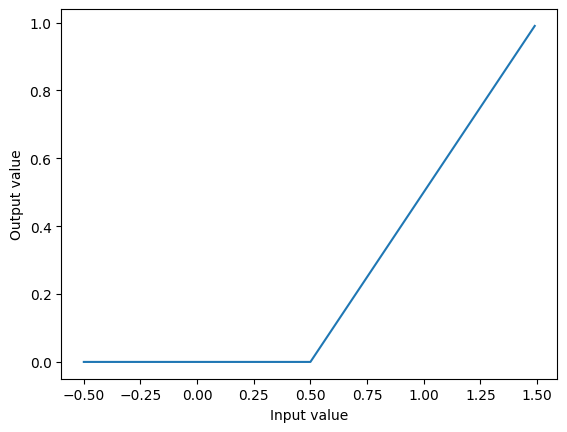

In [106]:
import matplotlib.pyplot as plt
def plot_activation(neuron):
     outputs = []
     for x in range(-50,150):
         n0.value = x/100
         outputs.append(neuron.activate())
     plt.plot([x/100 for x in range(-50,150)], outputs)
     plt.xlabel('Input value')
     plt.ylabel('Output value')
     plt.show()

plot_activation(n1)

Durch Verketten von mehreren Neuronen können wir komplexere Netzwerke erstellen, die in der Lage sind, kompliziertere Funktionen darzustellen.
- Wir erstellen ein kleines Netzwerk mit 4 Neuronen um die sogenannte Hutfunktion darzustellen

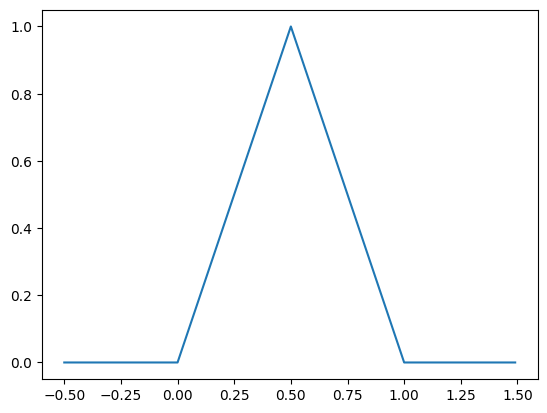

In [102]:
n0 = Input(1.0)
n1 = Neuron([n0], [1.0], 0.0)
n2 = Neuron([n0], [1.0], -0.5)
n3 = Neuron([n0], [1.0], -1.0)
n4 = Neuron([n1, n2, n3], [2.0, -4.0, 2.0], 0.0)
plot_activation(n4)

### Matrixdarstellung von Neuronalen Netzwerken
Anstatt jedes Neuron einzeln zu betrachten können wir eine gesamte Schicht von Neuronen als Matrixoperation darstellen.
- Eingabevektor $x$
- Gewichtsmatrizen $W_0, W_1, \ldots$ für jede Schicht
- Bias-Vektoren $b_0, b_1, \ldots$ für jede Schicht
- Aktivierungsfunktionen $f$ werden auf die Ergebnisse angewendet
    - Dabei ist für einen Vektor $x\in \mathbb{R}^n$ die Aktivierungsfunktion definiert als

    $$
     f(x) = \begin{pmatrix} f(x_1) \\\ f(x_2) \\\ \vdots \\\ f(x_n) \end{pmatrix} \in \mathbb{R}^n
    $$

Ein allgemeines Neuronales Netzwerk hat also die Form:

$$
\text{Output}(x) = W_n f( W_{n-1} f( \ldots f(W_0 x + b_0) + b_{1} \ldots ) + b_{n-1}) + b_n
$$

Das obige Beispiel mit 4 Neuronen kann so dargestellt werden:

$$
\text{Output}(x) = \begin{pmatrix} 2.0 & -4.0 & 2.0\end{pmatrix} f\left(\begin{pmatrix} 1\\ 1\\ 1\end{pmatrix} x + \begin{pmatrix} 0.0\\ -0.5\\ -1.0\end{pmatrix}\right) + 0.0
$$

### Training von Neuronalen Netzwerken
Oft will man Neuronale Netzwerke erstellen, die gewisse Funktionen approximieren, z.B. Bildklassifikation:
- $\text{Output}(x) =1 $ bedeutet das Bild zeigt eine Katze
- $\text{Output}(x) =0 $ bedeutet das Bild zeigt keine Katze

Dazu benötigt man viele Trainingsdaten (Bilder mit und ohne Katzen), die man in Vektorform bringt.
- Jedes Bild wird in einen Vektor $x_i$, $i=1,\ldots, n$ umgewandelt (siehe, z.B., Kapitel 'Matrix-Vektor Operationen mit `NumPy`')
- In einem Vektor $y\in \mathbb{R}^n$ werden die zugehörigen Labels gespeichert (1 für Katze, 0 für keine Katze)

Dann wählt man die Gewichte und Biases des Neuronalen Netzwerks so, dass die Vorhersagen des Netzwerks für die Trainingsdaten möglichst genau sind.
- $\text{Output}(x_i) \approx y_i$ für alle Trainingsdaten $i=1,\ldots, n$

Dies geschieht meistens mit der Methode des Gradientenabstiegs (Gradient Descent):
- Dazu braucht man mehrdimensionale Ableitungen (Gradienten)
- Kettenregel für mehrdimensionale Funktionen
- Nicht in EPROG!


### Ein-Layer Neuronale Netzwerke
Wir beschränken uns im Folgenden auf besonders einfache Neuronale Netzwerke mit nur einer versteckten Schicht (One-Layer Neural Networks).
- Diese Netzwerke haben die Form:

$$
\text{Output}(x) = W_1 f( W_0 x + b_0)
$$

- Die versteckte Schicht ist $W_0$, $b_0$ (hidden layer)
- Die Ausgabeschicht ist $W_1$ (output layer)

- Zusätzlich fixieren wir die Werte der ersten Schicht $W_0$ und $b_0$ zufällig und wählen nur die Werte der zweiten Schicht $W_1$ speziell.
    - Wir haben bereits gesehen, dass die zufällige Wahl von Vektoren (mit Normalverteilung) sehr viele fast orthogonale Vektoren erzeugt. Dies hilft dabei, dass die Neuronen in der versteckten Schicht unterschiedliche Aspekte der Eingabedaten erfassen.
- Die zweite Schicht wird dann so gewählt, dass die Ausgaben des Netzwerks möglichst gut zu den Trainingsdaten passen.
    - Dazu erstellen wir zuerst die Matrix $M\in \mathbb{R}^{m\times n}$, deren Spalten die Ausgaben der versteckten Schicht für alle Trainingsdaten sind, also

    $$
    M = \Big(f(W_0x_0 + b_0), f(W_0x_1 + b_0), \ldots, f(W_0x_n + b_0)\Big)
    $$

    - Dann erstellen wir den Datenvektor $y\in \mathbb{R}^{1\times n}$ mit den zugehörigen Labels (z.B., 1 für Katze, 0 für keine Katze).
    - Schließlich wählen wir $W_1\in \mathbb{R}^{1\times m}$ so, dass die Vorhersagen des Netzwerks möglichst gut zu den Labels passen, also $W_1 M \approx y$ oder äquivalent $M^T W_1^T \approx y^T$.
        - Falls $m = n$, geschieht dies mit $W_1^T=x$ durch Lösen des linearen Gleichungssystems

        $$
        M^Tx = y^T.
        $$

        - Der realistischere Fall ist $m<n$. Dann kann man mit die Methode der kleinsten Quadrate anwenden, also man löst das Gleichungssystem

        $$
        M M^T x = M y^T.
        $$  

    - Man kann zeigen, dass dies den Fehler $\|W_1 M - y\|_2$ minimiert.

In [2]:
import numpy as np
class NeuralNet:
    def __init__(self,input_size, hidden_size):
        self.W0 = np.random.randn(hidden_size, input_size) * 0.01
        self.b0 = np.random.randn(hidden_size, 1)*0.01
        self.W1 = np.zeros((1, hidden_size))

    def optimize(self, x_data, y_data):
        M = np.maximum(self.W0 @ x_data + self.b0, 0)     
        self.W1 = np.linalg.solve(M @ M.T, M @ y_data.T).T

    def predict(self, x):
        M = np.maximum(self.W0 @ x + self.b0, 0)
        return self.W1 @ M

### Beispiel: Approximation der Hutfunktion

Wir können die Methode testen, indem wir versuchen, die Hutfunktion von oben zu approximieren
- Anstelle die versteckte Schicht zufällig zu wählen, setzen wir die Gewichte und Biases wie im vorherigen Beispiel ein
- Dann optimieren wir nur die Gewichte der Ausgabeschicht mit der obigen Methode

[[ 2. -4.  2.]]


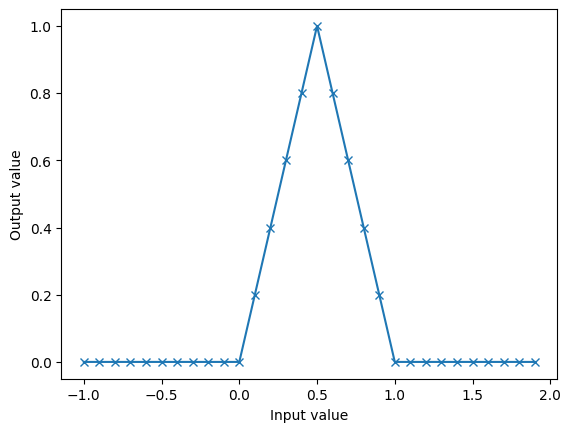

In [3]:
x_data = np.array([[-0.5, 0, 0.5, 1, 1.5]])
y_data = np.array([[ 0  , 0, 1  , 0, 0  ]])

nn = NeuralNet(input_size=1, hidden_size=3)
nn.W0 = np.array([[1.0], [1.0], [1.0]])
nn.b0 = np.array([[0.0], [-0.5], [-1.0]])
nn.optimize(x_data, y_data)

print(nn.W1)

import matplotlib.pyplot as plt
x_test = np.arange(-1,2,0.1).reshape(1,-1)
predictions = nn.predict(x_test)
plt.plot(x_test.flatten(), predictions.flatten(), '-x', label='Predictions')
plt.xlabel('Input value')
plt.ylabel('Output value')
plt.show()

## Beispiel: Handschrifterkennung mit Neuronalen Netzwerken


Als interessanteres Beispiel betrachten wir die Erkennung von handgeschriebenen Ziffern mit unserem Neuronalen Netzwerk
- Wir verwenden den MNIST-Datensatz, der 70.000 Bilder von handgeschriebenen Ziffern (0-9) enthält (frei verfügbar im Internet)
- Jedes Bild hat die Größe 28x28 Pixel, also 784 Pixel insgesamt
- Die Bilder sind als Numpy-Arrays gespeichert.
- Es gibt 60.000 Trainingsbilder zum Trainieren des Netzwerks und 10.000 Testbilder zum Testen der Genauigkeit des Netzwerks nach dem Training.


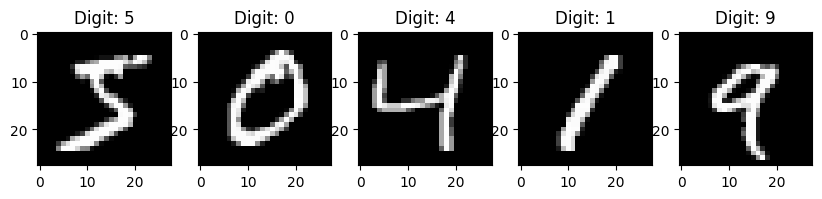

In [4]:
import numpy as np
import matplotlib.pyplot as plt
data = np.load('data/mnist_data.npy',allow_pickle=True).item()
x_train = data['x_train']
y_train = data['y_train']
x_test = data['x_test']
y_test = data['y_test']

def show_samples(x_train, y_train):
    N = x_train.shape[0]
    plt.subplots(1,N, figsize=(2*N,4))
    for i in range(N):
        plt.subplot(1,N,i+1)
        plt.imshow(x_train[i].reshape(28,28), cmap='gray')
        plt.title(f'Digit: {y_train[i]}')
    plt.show()

show_samples(x_train[:5], y_train[:5])

Wir wandeln jedes Bild in einen Vektor $x_i\in \mathbb{R}^{784}$ um, $i=1,\ldots, 60000$ für die Trainingsdaten um.
- Analog für die Testdaten mit $i=1,\ldots, 10000$
- Die Pixelwerte werden normalisiert, indem sie durch 255 geteilt werden, sodass alle Werte im Bereich $[0,1]$ liegen.

Die Labels der Trainingsdaten werden in die sogenannte One-Hot-Codierung umgewandelt:
- $y \in \mathbb{R}^{10\times 60000}$ mit
    - $y_{jk} = 1$ wenn das $k$-te Trainingsbild die Ziffer $j$ zeigt
    - $y_{jk} = 0$ sonst
- Der Grund ist, dass sonst benachbarte Ziffern (z.B., 3 und 4) leichter verwechselt werden könnten, wenn nur eine einzelne Zahl als Label verwendet wird.

In [5]:
x_train = x_train.reshape(x_train.shape[0], -1).T / 255.0
x_test = x_test.reshape(x_test.shape[0], -1).T / 255.0
y_train = np.eye(10)[y_train].T
print(f"Shape of x_train: {x_train.shape}, Shape of y_train: {y_train.shape}")

Shape of x_train: (784, 60000), Shape of y_train: (10, 60000)


Wir erweitern unser Neuronales Netzwerk so, dass die Output-Dimension 10 ist. 
- Wir optimieren also 10 verschiedene Gewichtsvektoren $W_1^{(1)}$, $W_1^{(2)}$, ..., $W_1^{(10)}$
- $W_1^{(i)}$ wird so gewählt, dass der Output $1$ ist, falls das Bild die Ziffer $i$ zeigt, und $0$ sonst.
- Wir redefinieren die `predict`-Methode so, dass sie die Ziffer mit dem höchsten Output-Wert zurückgibt.

In [33]:
class NeuralNet2(NeuralNet):
    def __init__(self, input_size, hidden_size, output_size):
        super().__init__(input_size, hidden_size)
        self.W1 = np.zeros((output_size, hidden_size))

    def optimize(self, x_data, y_data):
        M = np.maximum(self.W0 @ x_data + self.b0, 0)  
        for i in range(self.W1.shape[0]):
            self.W1[i,:] = np.linalg.solve(M @ M.T, M @ y_data[i].T).T

    def predict(self, x):
        M = np.maximum(self.W0 @ x + self.b0, 0)
        return np.argmax(self.W1 @ M, axis=0)

Jetzt können wir das Netzwerk erstellen, trainieren und testen.
- Wir erstellen mehrere Netzwerke mit unterschiedlicher Anzahl von Neuronen in der versteckten Schicht (z.B., 10, 50, 100, 500, 1000)

In [34]:
import time
nn10 = NeuralNet2(input_size=x_train.shape[0], hidden_size=10, output_size=10)
nn50 = NeuralNet2(input_size=x_train.shape[0], hidden_size=50, output_size=10)
nn100 = NeuralNet2(input_size=x_train.shape[0], hidden_size=100, output_size=10)
nn500 = NeuralNet2(input_size=x_train.shape[0], hidden_size=500, output_size=10)
nn1000 = NeuralNet2(input_size=x_train.shape[0], hidden_size=1000, output_size=10)

for nn in [nn10, nn50, nn100, nn500, nn1000]:
    start_time = time.time()
    nn.optimize(x_train, y_train)
    end_time = time.time()
    print(f"Hidden neurons: {nn.W0.shape[0]}, Training time: {end_time - start_time:.2f}s")

Hidden neurons: 10, Training time: 0.05s
Hidden neurons: 50, Training time: 0.12s
Hidden neurons: 100, Training time: 0.21s
Hidden neurons: 500, Training time: 2.12s
Hidden neurons: 1000, Training time: 5.37s


Die Fehlerrate im Testdatensatz hängt stark davon ab, wie groß die versteckte Schicht gewählt wird.

In [35]:
sizes = [10, 50, 100, 500, 1000]
for i, nn in enumerate([nn10, nn50, nn100, nn500, nn1000]):
    predictions = nn.predict(x_test)
    print(f"Error rate in test set (size {sizes[i]}): {np.sum(predictions != y_test) / y_test.shape[0]:%}")


Error rate in test set (size 10): 69.800000%
Error rate in test set (size 50): 26.020000%
Error rate in test set (size 100): 17.200000%
Error rate in test set (size 500): 8.230000%
Error rate in test set (size 1000): 5.880000%


Show some predictions of NN with 10 hidden neurons


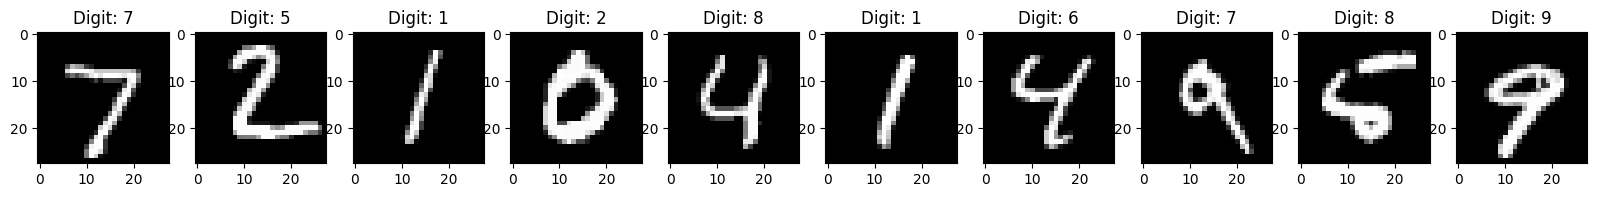

Show some predictions of NN with 50 hidden neurons


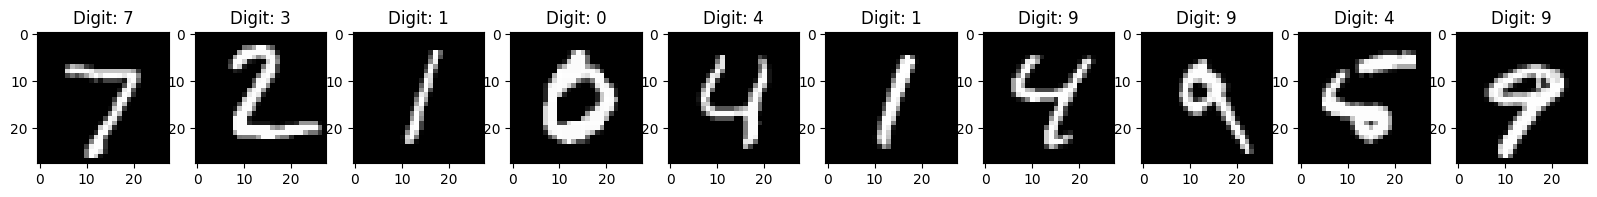

Show some predictions of NN with 500 hidden neurons


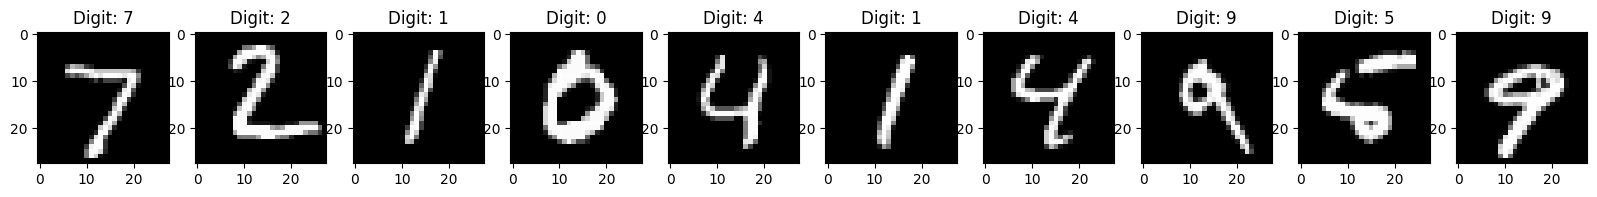

In [36]:
print("Show some predictions of NN with 10 hidden neurons")
show_samples(x_test[:, :10].T, nn10.predict(x_test[:, :10]))
print("Show some predictions of NN with 50 hidden neurons")
show_samples(x_test[:, :10].T, nn50.predict(x_test[:, :10]))
print("Show some predictions of NN with 500 hidden neurons")
show_samples(x_test[:, :10].T, nn500.predict(x_test[:, :10]))

Wir können nun auch Bilder außerhalb des Datensatzes testen.

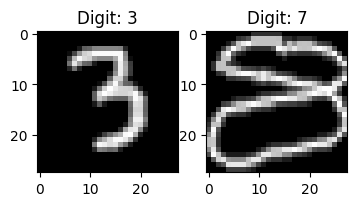

In [37]:
x0 = np.mean(plt.imread('data/digit.png'),axis=2)
x1 = np.mean(plt.imread('data/digit2.png'),axis=2)
x = np.zeros((28*28,2))
x[:,0] = x0.flatten()
x[:,1] = x1.flatten()
prediction = nn1000.predict(x)
show_samples(x.T, prediction)
